# DDIM v4 — Inference Steps Sweep


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [2]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR = WORKSPACE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)
print('RUNS_DIR       =', RUNS_DIR)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data
RUNS_DIR       = c:\Users\User\source\repos\genai-project1\runs


In [4]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf  = hf_ds["test"]

print("Train size:", len(train_hf))
print("Test size :", len(test_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Test size : 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


In [7]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, subsets=50, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [8]:
# ── FID/KID evaluation — shared config & helpers ─────────────────
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs        = RUNS_DIR if "RUNS_DIR" in globals() else Path("runs")
_results_out = _runs / "evaluation_results.json"


def _best_row(csv_path, key_col, lower_is_better=True):
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


def _load_results():
    if _results_out.exists():
        with open(_results_out) as f:
            return _json.load(f)
    return {}


def _save_results(d):
    _runs.mkdir(parents=True, exist_ok=True)
    with open(_results_out, "w") as f:
        _json.dump(d, f, indent=2)
    print(f"Saved → {_results_out}")


def _print_results(d):
    if not d:
        print("No results yet.")
        return
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in d.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )

print("FID/KID config ready. Run each model cell independently.")
print(f"Results file: {_results_out}")
if _results_out.exists():
    _print_results(_load_results())


FID/KID config ready. Run each model cell independently.
Results file: c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              195.70     1.00     185.9775       1.3450
DCGAN_FULL       202.48     0.69      91.7944       1.1543
DDPM_FULL         69.46     0.87      47.8215       1.1552
DDIM_FULL         45.01     0.48      24.9569       1.1207
DDIM_V2_ADAMW      45.15     0.48      25.0451       1.1122
DDIM_V3_LARGEUNET      65.50     0.46      49.2965       0.8478
DDIM_V4_STEPS250      43.18     0.46      23.7046       0.9970
DDIM_V4_STEPS500      49.64     0.60      31.6956       0.6545
DDIM_FULL_OPT_COSINE_EP300      57.75     0.87      32.7391       0.8330
DDIM_FULL_ATTN      63.68     0.96      42.8180       1.4888
DCGAN_V3         102.29     0.87      84.2452       1.4502
DDIM_V4_STEPS225      45.51     0.45      23.4626       0.7586

In [9]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Full 50k loader — normalized [-1,1] — used by DCGAN, DDPM, DDIM
_transform_full = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])

train_ds_full = HFDatasetTorch(train_hf, transform=_transform_full, indices=None)
train_loader_full = DataLoader(
    train_ds_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Test dataset — unnormalized [0,1] — used by FID/KID evaluation
_transform_eval = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
])
test_ds = HFDatasetTorch(test_hf, transform=_transform_eval, indices=None)

print(f"Full train dataset : {len(train_ds_full):,} images")
print(f"Test dataset       : {len(test_ds):,} images")
print(f"Batches per epoch  : {len(train_loader_full)}")


Full train dataset : 50,000 images
Test dataset       : 10,000 images
Batches per epoch  : 782


---
# DDPM / DDIM — Class Definitions

Identical to Full_training.ipynb.

In [10]:
"""DDPM for ArtBench-10."""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def sinusoidal_embeddings(n_steps: int, dim: int) -> torch.Tensor:
    """Fixed sinusoidal embeddings table (interleaved sin/cos), shape (n_steps, dim)."""
    emb = torch.zeros(n_steps, dim)
    position = torch.arange(0, n_steps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
    emb[:, 0::2] = torch.sin(position * div_term)
    emb[:, 1::2] = torch.cos(position * div_term)
    return emb


def _get_groups(channels: int, num_groups: int = 8) -> int:
    """Find largest divisor of channels that is <= num_groups."""
    g = max(1, min(num_groups, channels))
    while channels % g != 0:
        g -= 1
    return g


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, num_groups: int = 8, dropout: float = 0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(_get_groups(in_channels, num_groups), in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_emb_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = nn.GroupNorm(_get_groups(out_channels, num_groups), out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_emb_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)


class DownBlock(nn.Module):
    """Two ResBlocks (maintain channels) + strided conv that changes channels."""

    def __init__(self, channels: int, next_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.res1 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.down = nn.Conv2d(channels, next_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor):
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        skip = x          # saved before downsampling, at original channels
        x = self.down(x)  # spatial downsample + channel change
        return x, skip


class UpBlock(nn.Module):
    """Transposed conv + concat skip + two ResBlocks."""

    def __init__(self, in_channels: int, out_channels: int, skip_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res1 = ResBlock(out_channels + skip_channels, out_channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(out_channels, out_channels, time_emb_dim, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor, time_emb: torch.Tensor):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        return x


class UNet(nn.Module):
    """UNet for diffusion denoising. Structurally identical to UNet32 from Antonio's notebook."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        dropout: float = 0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256]

        self.time_emb_dim = time_emb_dim
        self.hidden_dims = hidden_dims

        # Timestep embedding: fixed sinusoidal lookup, then MLP
        embed_dim = hidden_dims[0]
        self.time_embed = nn.Embedding(num_steps, embed_dim)
        self.time_embed.weight.data = sinusoidal_embeddings(num_steps, embed_dim)
        self.time_embed.weight.requires_grad = False

        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.initial_conv = nn.Conv2d(img_channels, hidden_dims[0], kernel_size=3, padding=1)

        # Down path: len(hidden_dims) levels, 32 -> 16 -> 8 -> 4
        # Channels at each level: hidden_dims[i]
        # Downsampling conv changes to hidden_dims[i+1] (last level stays same)
        self.downs = nn.ModuleList()
        for i, ch in enumerate(hidden_dims):
            next_ch = hidden_dims[i + 1] if i < len(hidden_dims) - 1 else hidden_dims[-1]
            self.downs.append(DownBlock(ch, next_ch, time_emb_dim, dropout=dropout))

        # Bottleneck at 4x4
        self.mid1 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)
        self.mid2 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)

        # Up path: len(hidden_dims) levels, 4 -> 8 -> 16 -> 32
        # skip channels = hidden_dims reversed (d3=256, d2=128, d1=64)
        # upsample channel pattern: 256->256->128->64
        self.ups = nn.ModuleList()
        rev = list(reversed(hidden_dims))   # [256, 128, 64]
        in_ch = hidden_dims[-1]
        for i, skip_ch in enumerate(rev):
            out_ch = rev[i]
            self.ups.append(UpBlock(in_ch, out_ch, skip_ch, time_emb_dim, dropout=dropout))
            in_ch = out_ch

        # Final output: GroupNorm + SiLU + Conv
        out_ch = hidden_dims[0]
        self.out = nn.Sequential(
            nn.GroupNorm(_get_groups(out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Noisy image (B, C, H, W)
            t: Timestep indices (B,) as long integers

        Returns:
            predicted_noise: (B, C, H, W)
        """
        t_emb = self.time_mlp(self.time_embed(t.long()))

        x = self.initial_conv(x)

        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)


class DiffusionScheduler(nn.Module):
    """Linear diffusion schedule with registered buffers."""

    def __init__(self, num_steps: int = 1000, beta_start: float = 1e-4, beta_end: float = 2e-2):
        super().__init__()

        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alpha_cumprod = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat([torch.ones(1), alpha_cumprod[:-1]], dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("alpha_cumprod_prev", alpha_cumprod_prev)

        self.register_buffer("sqrt_alpha_cumprod", torch.sqrt(alpha_cumprod))
        self.register_buffer("sqrt_one_minus_alpha_cumprod", torch.sqrt(1.0 - alpha_cumprod))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alphas))

        posterior_variance = betas * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod)
        self.register_buffer("posterior_variance", torch.clamp(posterior_variance, min=1e-20))

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise"""
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x_0
            + self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1) * noise
        )


class Diffusion(nn.Module):
    """DDPM — Denoising Diffusion Probabilistic Models (Ho et al. 2020)."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.num_steps = num_steps

        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims,
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )

        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        shape: tuple = (3, 32, 32),
        device: torch.device | str | None = None,
        num_inference_steps: int | None = None,
    ) -> torch.Tensor:
        """Generate samples via reverse diffusion. Returns images in [0, 1]."""
        self.eval()

        if device is None:
            device = next(self.parameters()).device
        if isinstance(device, str):
            device = torch.device(device)

        if num_inference_steps is None:
            timesteps = torch.arange(self.num_steps - 1, -1, -1, device=device)
        else:
            timesteps = torch.linspace(self.num_steps - 1, 0, num_inference_steps, device=device).long()

        x = torch.randn(num_samples, *shape, device=device)

        for t_scalar in timesteps:
            t_idx = int(t_scalar.item())
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)

            beta_t = self.scheduler.betas[t_idx].view(1, 1, 1, 1)
            sqrt_one_minus_abar = self.scheduler.sqrt_one_minus_alpha_cumprod[t_idx].view(1, 1, 1, 1)
            sqrt_recip_alpha = self.scheduler.sqrt_recip_alphas[t_idx].view(1, 1, 1, 1)

            pred_noise = self.unet(x, t)
            model_mean = sqrt_recip_alpha * (x - beta_t * pred_noise / (sqrt_one_minus_abar + 1e-8))

            if t_idx > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

        return torch.clamp(x, 0, 1)


In [11]:
"""DDIM — Denoising Diffusion Implicit Models.

Training is identical to DDPM (predict noise, MSE loss).
Sampling is deterministic (eta=0) using a subsequence of timesteps.
Reuses UNet, DiffusionScheduler, and sinusoidal_embeddings from the DDPM section.
"""


class DDIM(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_steps = num_steps
        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims or [64, 128, 256],
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )
        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        """Training forward: same as DDPM."""
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(self, num_samples: int, shape: tuple, device, num_inference_steps: int = 200) -> torch.Tensor:
        """Deterministic DDIM sampling (eta=0)."""
        self.eval()
        abar = self.scheduler.alpha_cumprod.to(device)

        # evenly spaced subsequence T-1 → 0
        step = max(1, self.num_steps // num_inference_steps)
        timesteps = torch.arange(self.num_steps - 1, -1, -step, device=device)[:num_inference_steps]

        x = torch.randn(num_samples, *shape, device=device)

        for i, t_scalar in enumerate(timesteps):
            t_idx      = int(t_scalar.item())
            t_prev_idx = int(timesteps[i + 1].item()) if i + 1 < len(timesteps) else -1

            abar_t    = abar[t_idx]
            abar_prev = abar[t_prev_idx] if t_prev_idx >= 0 else torch.ones(1, device=device).squeeze()

            t_batch = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)
            eps = self.unet(x, t_batch)

            # predicted x0
            x0_pred = (x - torch.sqrt(1 - abar_t) * eps) / (torch.sqrt(abar_t) + 1e-8)
            x0_pred = x0_pred.clamp(-1, 1)

            # DDIM step (deterministic)
            x = torch.sqrt(abar_prev) * x0_pred + torch.sqrt(1 - abar_prev) * eps

        return x.clamp(0, 1)


## Inference Experiments

In [12]:
# Load v1 checkpoint — shared by all inference experiments
import torch
from pathlib import Path

_V1_RUN   = "ddim_full_ep100_seed42"
_best     = RUNS_DIR / _V1_RUN / "checkpoints" / "best_model.pt"
_final    = RUNS_DIR / _V1_RUN / "checkpoints" / "final_model.pt"
_ckpt_path = _best if _best.exists() else _final

print(f"Loading: {_ckpt_path}")
_ckpt = torch.load(_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
_cfg  = _ckpt["config"]

_ddim_v1 = DDIM(
    img_channels=_cfg["img_channels"], hidden_dims=_cfg["hidden_dims"],
    time_emb_dim=_cfg["time_emb_dim"], num_steps=_cfg["num_diffusion_steps"],
).to(EVAL_DEVICE)
_ddim_v1.load_state_dict(_ckpt["model_state_dict"])
_ddim_v1.eval()
print(f"Model loaded | hidden_dims={_cfg['hidden_dims']} | num_steps={_cfg['num_diffusion_steps']}")


Loading: c:\Users\User\source\repos\genai-project1\runs\ddim_full_ep100_seed42\checkpoints\best_model.pt
Model loaded | hidden_dims=[64, 128, 256] | num_steps=1000


### 250 Inference Steps

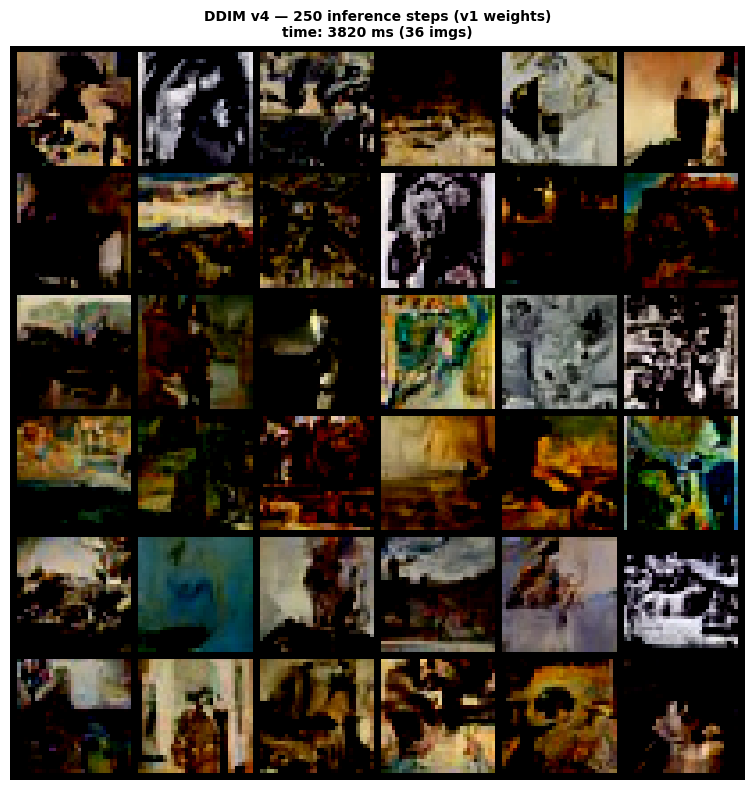

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_250steps.png


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [diffusion] Rep 1/10 seed=0 | FID=42.94 | KID=23.7961±4.6270 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=43.02 | KID=23.2847±4.3992 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=43.90 | KID=23.6960±4.8825 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=43.46 | KID=24.8606±4.7229 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=42.92 | KID=23.2898±4.0691 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=42.51 | KID=22.0847±4.2157 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=43.69 | KID=24.9901±4.3892 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=43.69 | KID=25.2950±4.5877 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=42.60 | KID=22.6984±4.2843 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=43.06 | KID=23.0508±3.6762 (×10⁻³)

  DIFFUSION | FID: 43.18 ± 0.46 | KID: 23.7046 ± 0.9970 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
DDIM_V4

In [13]:
# DDIM v4 — 250 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 250
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 250 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


### 500 Inference Steps

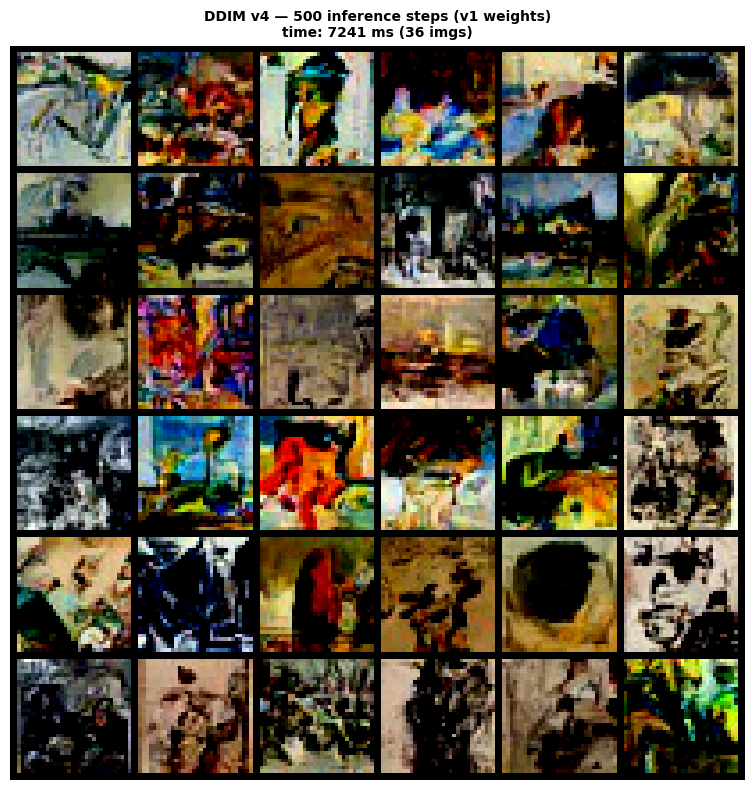

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_500steps.png
  [diffusion] Rep 1/10 seed=0 | FID=49.41 | KID=32.6208±4.9514 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=49.96 | KID=31.3918±6.0580 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=50.65 | KID=32.0035±5.4639 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=50.36 | KID=32.3229±5.2242 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=49.39 | KID=31.2814±5.5572 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=49.36 | KID=31.1073±4.7498 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=49.94 | KID=32.3020±5.4103 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=49.80 | KID=32.2958±4.8750 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=48.62 | KID=30.9748±5.3187 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=48.88 | KID=30.6557±4.9212 (×10⁻³)

  DIFFUSION | FID: 49.64 ± 0.60 | KID: 31.6956 ± 0.6545 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±

In [14]:
# DDIM v4 — 500 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 500
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 500 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


### 225 Inference Steps

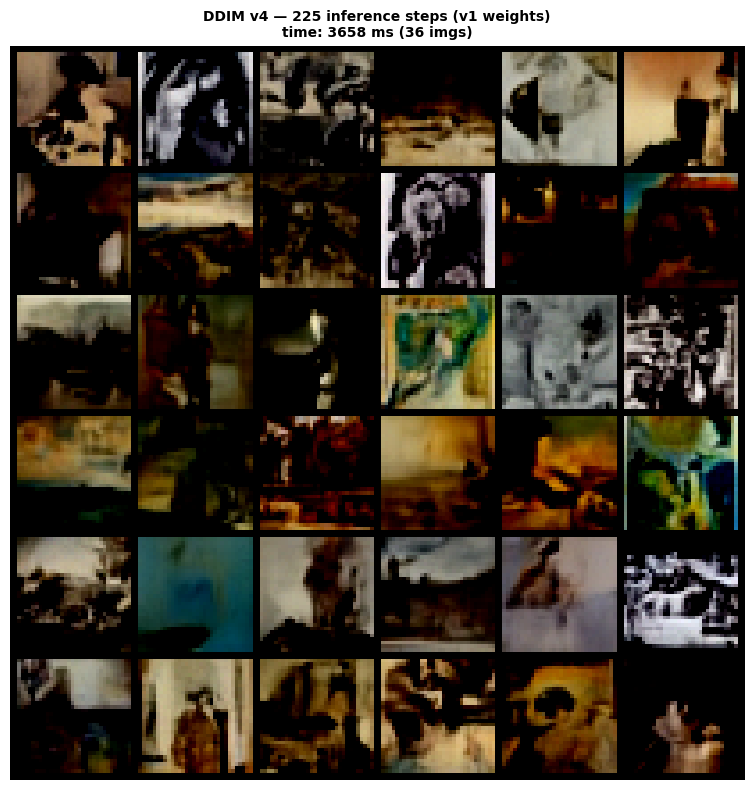

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_225steps.png


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [diffusion] Rep 1/10 seed=0 | FID=44.76 | KID=22.1642±4.1579 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=45.53 | KID=23.5822±3.3038 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=45.52 | KID=23.1668±3.8215 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=45.81 | KID=24.2833±3.5096 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=44.84 | KID=22.8165±3.0563 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=45.38 | KID=22.9109±4.4218 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=46.06 | KID=24.2985±3.9796 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=46.17 | KID=24.7975±3.7592 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=45.25 | KID=23.1607±3.5331 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=45.78 | KID=23.4454±2.9391 (×10⁻³)

  DIFFUSION | FID: 45.51 ± 0.45 | KID: 23.4626 ± 0.7586 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
DDIM_V4

In [13]:
# DDIM v4 — 225 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 225
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 225 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


### 275 Inference Steps

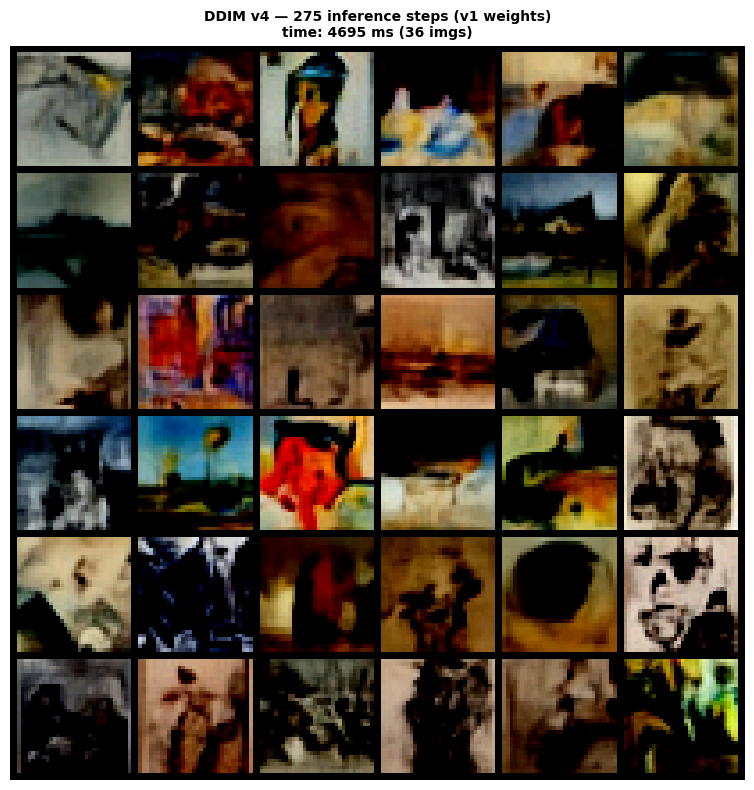

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_275steps.png
  [diffusion] Rep 1/10 seed=0 | FID=53.55 | KID=30.2307±5.3999 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=54.02 | KID=32.2751±4.7636 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=54.29 | KID=32.5452±4.8123 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=54.54 | KID=31.9152±4.1327 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=53.61 | KID=30.9456±3.5838 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=54.36 | KID=31.5600±5.4747 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=54.67 | KID=32.5178±5.1175 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=54.87 | KID=32.7101±4.5203 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=54.04 | KID=31.7142±4.0724 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=54.79 | KID=32.5634±4.1983 (×10⁻³)

  DIFFUSION | FID: 54.27 ± 0.44 | KID: 31.8977 ± 0.7670 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±

In [14]:
# DDIM v4 — 275 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 275
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 275 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


### 300 Inference Steps

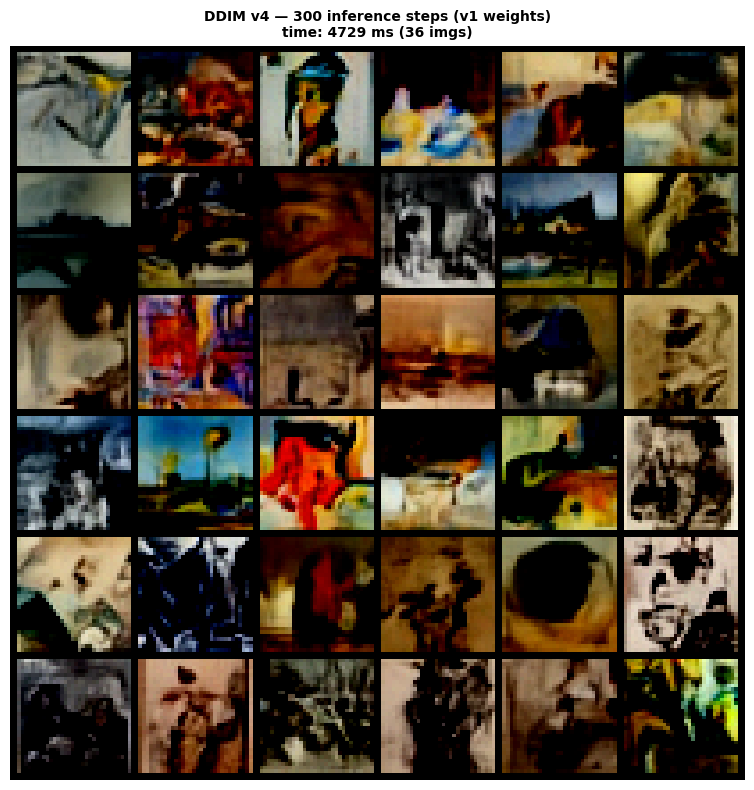

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_300steps.png
  [diffusion] Rep 1/10 seed=0 | FID=42.64 | KID=20.6815±3.8727 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=43.15 | KID=21.8457±3.5504 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=42.78 | KID=21.0920±3.4775 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=43.29 | KID=21.6402±3.1142 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=42.25 | KID=20.6917±2.9148 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=42.81 | KID=20.9786±4.0362 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=43.12 | KID=21.5826±3.5071 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=43.33 | KID=22.1723±3.6193 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=42.44 | KID=20.9590±3.3469 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=42.97 | KID=21.0982±2.7873 (×10⁻³)

  DIFFUSION | FID: 42.88 ± 0.34 | KID: 21.2742 ± 0.4800 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±

In [15]:
# DDIM v4 — 300 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 300
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 300 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


### 333 Inference Steps

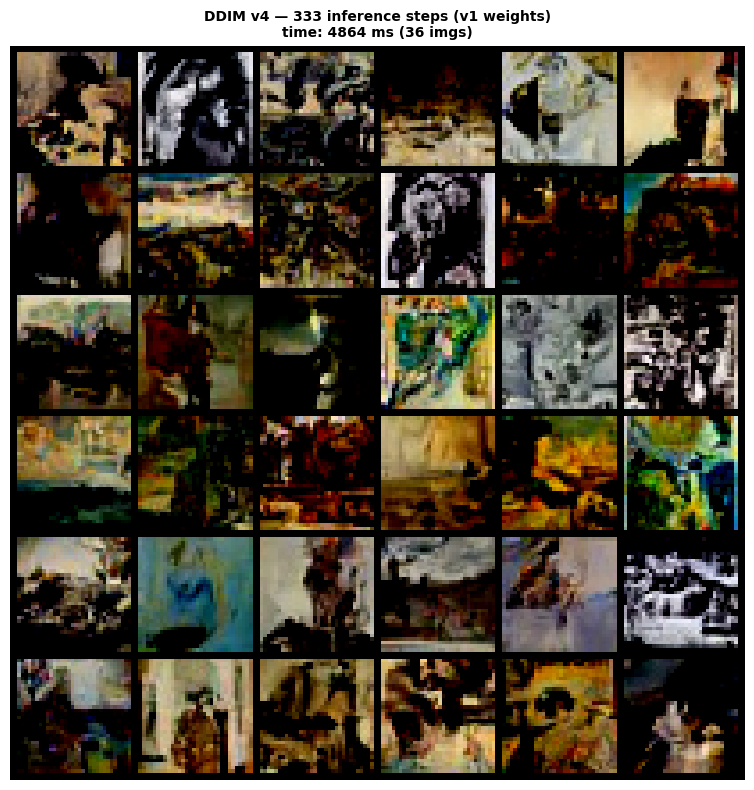

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_v4_samples_333steps.png


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [diffusion] Rep 1/10 seed=0 | FID=43.08 | KID=24.8587±4.4974 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=43.33 | KID=24.0593±4.8958 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=43.89 | KID=24.5271±4.7792 (×10⁻³)


In [ ]:
# DDIM v4 — 333 inference steps
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid

_STEPS = 333
_run_key = f"ddim_v4_steps{_STEPS}"

# ── Samples ──────────────────────────────────────────────────────────
_t0 = _time_mod.perf_counter()
with torch.no_grad():
    _imgs = _ddim_v1.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), EVAL_DEVICE, _STEPS)
_t1 = _time_mod.perf_counter()

_grid = make_grid(_imgs, nrow=6, padding=2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_grid.permute(1, 2, 0).cpu().numpy())
ax.axis('off')
ax.set_title(
    'DDIM v4 — 333 inference steps (v1 weights)\n'
    f'time: {(_t1-_t0)*1000:.0f} ms (36 imgs)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = RUNS_DIR / 'figures' / f'ddim_v4_samples_{_STEPS}steps.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

# ── FID/KID ───────────────────────────────────────────────────────────
_res = evaluate_model(
    model=_ddim_v1, real_dataset=test_ds, model_type='diffusion',
    latent_dim=0, img_channels=_cfg['img_channels'], img_size=_cfg['img_size'],
    num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
    kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
    base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    num_inference_steps=_STEPS,
)
_all = _load_results()
_all[_run_key] = _res
_save_results(_all)
_print_results({_run_key: _res})


## Results — Full Sweep

In [ ]:
# Full steps sweep comparison
_all = _load_results()

print("\n--- DDIM Inference Steps Sweep (same v1 weights) ---")
print(f"{'Steps':>7} {'FID':>8} {'FID+-':>7} {'KID*1e3':>10}  coverage")
print("-" * 55)
for steps, key, coverage in [
    (200,  "ddim_full",        "complete (step=5)"),
    (225,  "ddim_v4_steps225", "truncated at t=103"),
    (250,  "ddim_v4_steps250", "complete (step=4)"),
    (275,  "ddim_v4_steps275", "truncated at t=177"),
    (300,  "ddim_v4_steps300", "truncated at t=102"),
    (333,  "ddim_v4_steps333", "complete (step=3, t>=3)"),
    (500,  "ddim_v4_steps500", "complete (step=2)"),
]:
    if key in _all:
        r = _all[key]
        best = min(v['fid_mean'] for v in _all.values() if 'fid_mean' in v)
        marker = " <--" if abs(r['fid_mean'] - best) < 0.01 else ""
        print(f"{steps:>7} {r['fid_mean']:>8.3f} {r['fid_std']:>7.3f} {r['kid_mean']*1e3:>10.2f}  {coverage}{marker}")
    else:
        print(f"{steps:>7} {'--':>8}  {coverage}")
